<div style="background-color:#111827;
padding:25px;
border-left:8px solid #F59E0B;
border-radius:10px;
margin-bottom:20px;">

<h1 style="color:white;
font-size:34px;
margin:0;">
Detección de Fraudes Bancarios
</h1>

<p style="color:#D1D5DB;
font-size:16px;
margin-top:10px;">
XGBoost con Score de Anomalía de Isolation Forest para Detección de Fraudes
</p>

</div>

**Isolation Forest** es un algoritmo de detección de anomalías basado en árboles aleatorios que parte de la premisa de que las observaciones anómalas son más fáciles de aislar que las normales, ya que requieren un menor número de particiones para quedar separadas del resto de los datos. Al aplicar este algoritmo sobre el conjunto de transacciones, se obtiene para cada observación un score de anomalía, que refleja el grado de rareza o desviación respecto al comportamiento habitual. Este score se incorpora posteriormente como una nueva característica de entrada para entrenar el modelo **XGBoost**, dando lugar a un enfoque de **Stacking Híbrido**. De esta manera, XGBoost puede aprender a interpretar la información proporcionada por Isolation Forest y determinar, en combinación con el resto de las variables, si una transacción corresponde o no a un fraude.

**Contenido del notebook:**

- EDA.  
- Isolation Forest.
- Aplicación de XGBoost con Score de Isolation Forest.  
- SHAP para el modelo supervisado.  

<h2 style="
background-color:#111827;
color:white;
padding:14px;
border-radius:10px;
border-left:6px solid #F59E0B;
font-size:28px;
">
Índice
</h2>

<div style="
background-color:#1F2937;
padding:20px;
border-radius:10px;
margin-top:10px;
color:#E5E7EB;
font-size:16px;
line-height:2;
">

<a href="#0" style="color:#D1D5DB; text-decoration:none;">
1. Preparación y limpieza de los datos
</a>
<br>

<a href="#1" style="color:#D1D5DB; text-decoration:none;">
2. Análisis exploratorio de datos (EDA)
</a>
<br>

<a href="#2" style="color:#D1D5DB; text-decoration:none;">
3. Modelado y evaluación
</a>
<br>

<a href="#4" style="color:#D1D5DB; text-decoration:none;">
4. Conclusiones
</a>

</div>

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">01</span>
Preparación y limpieza de los datos
</div>
<a id="0"></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import warnings

from great_tables import GT
from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (classification_report, confusion_matrix,
                              recall_score, precision_score, f1_score,
                              roc_auc_score, precision_recall_curve)
from xgboost import XGBClassifier, plot_importance

warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
plt.style.use('dark_background') # Usar tema oscuro para graficas.

In [3]:
df = pd.read_csv('creditcard1.csv')

In [4]:
# Separar features (X) y target (y)
X = df.drop('Class', axis=1)
y = df['Class']

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
GT(df.sample(5).round(2))

Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
64740.0,-1.29,1.51,2.32,2.79,-0.52,0.49,0.26,0.39,-1.31,0.91,0.21,0.47,1.5,-0.15,1.72,-0.13,0.25,-0.43,0.16,0.49,-0.03,0.17,-0.04,0.41,-0.05,0.14,0.21,-0.08,69.99,0
77674.0,1.35,-0.89,0.58,-0.78,-1.25,-0.27,-1.06,0.04,-0.18,0.62,-1.25,-1.49,-0.63,-0.27,1.3,1.78,-0.18,-0.44,0.53,0.13,0.34,0.79,-0.23,-0.44,0.49,0.0,0.02,0.02,54.0,0
125928.0,-1.13,0.52,1.63,-1.78,-0.34,0.08,-0.03,0.33,-1.37,0.23,0.26,0.77,1.3,-0.31,-0.69,-0.82,-0.68,1.52,-0.38,-0.27,-0.63,-1.27,-0.19,-0.52,0.16,0.34,-0.16,-0.19,13.95,0
171636.0,-0.56,1.48,-1.22,-1.05,0.63,-1.84,1.28,-0.0,-0.2,-0.36,-1.29,-0.59,-1.38,1.2,-0.07,-0.5,-0.19,-0.2,-0.14,-0.14,0.24,0.79,-0.18,-0.01,-0.27,0.1,0.37,0.26,0.77,0
61326.0,1.17,0.71,0.23,2.51,0.22,-0.57,0.49,-0.16,-1.06,0.7,-0.04,0.01,-0.23,0.59,0.45,-0.05,-0.07,-1.04,-1.37,-0.22,0.03,0.1,-0.03,0.4,0.61,0.08,-0.02,0.01,0.74,0


<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">02</span>
Análisis exploratorio de datos (EDA)
</div>
<a id="1"></a>

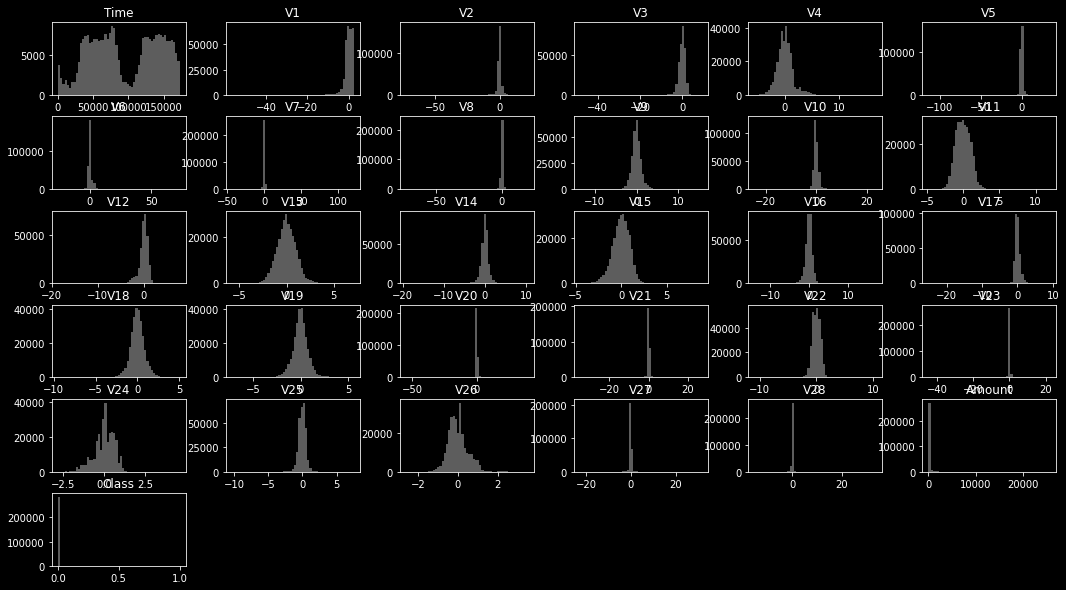

In [7]:
_=df.hist(grid=False, figsize=[18,10], color='#5d5d5d', bins=55)

In [8]:
(df.describe()
   .T.tail(10)
   .style
   .background_gradient(cmap='gist_gray')
   .format('{:.2f}'))

,count,mean,std,min,25%,50%,75%,max
V21,284807.00,0.00,0.73,-34.83,-0.23,-0.03,0.19,27.20
V22,284807.00,-0.00,0.73,-10.93,-0.54,0.01,0.53,10.50
V23,284807.00,0.00,0.62,-44.81,-0.16,-0.01,0.15,22.53
V24,284807.00,0.00,0.61,-2.84,-0.35,0.04,0.44,4.58
V25,284807.00,0.00,0.52,-10.30,-0.32,0.02,0.35,7.52
V26,284807.00,0.00,0.48,-2.60,-0.33,-0.05,0.24,3.52
V27,284807.00,-0.00,0.40,-22.57,-0.07,0.00,0.09,31.61
V28,284807.00,-0.00,0.33,-15.43,-0.05,0.01,0.08,33.85
Amount,284807.00,88.35,250.12,0.00,5.60,22.00,77.16,25691.16
Class,284807.00,0.00,0.04,0.00,0.00,0.00,0.00,1.00


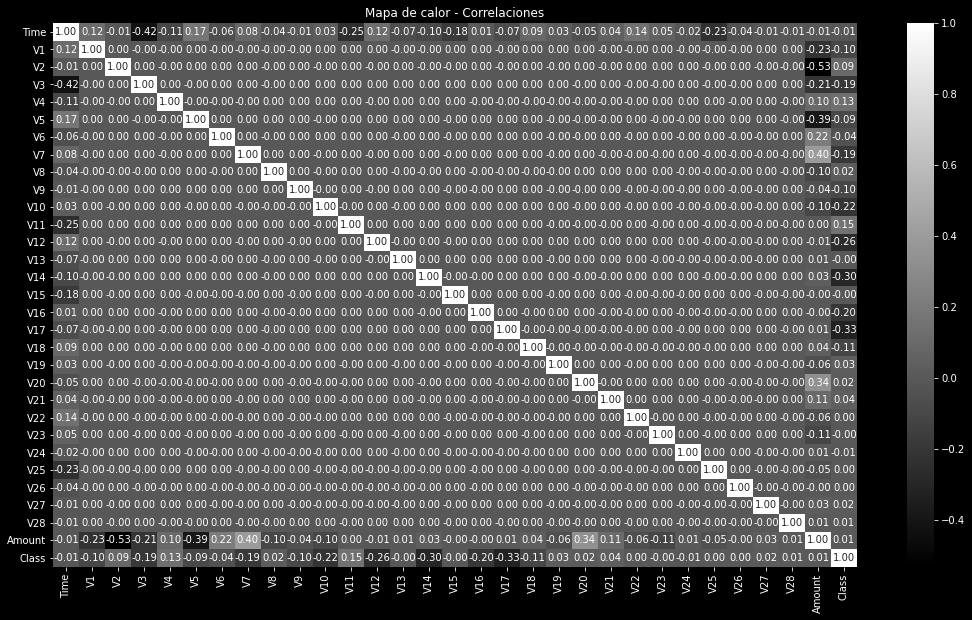

In [9]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='gist_gray')
plt.title('Mapa de calor - Correlaciones')
plt.show()

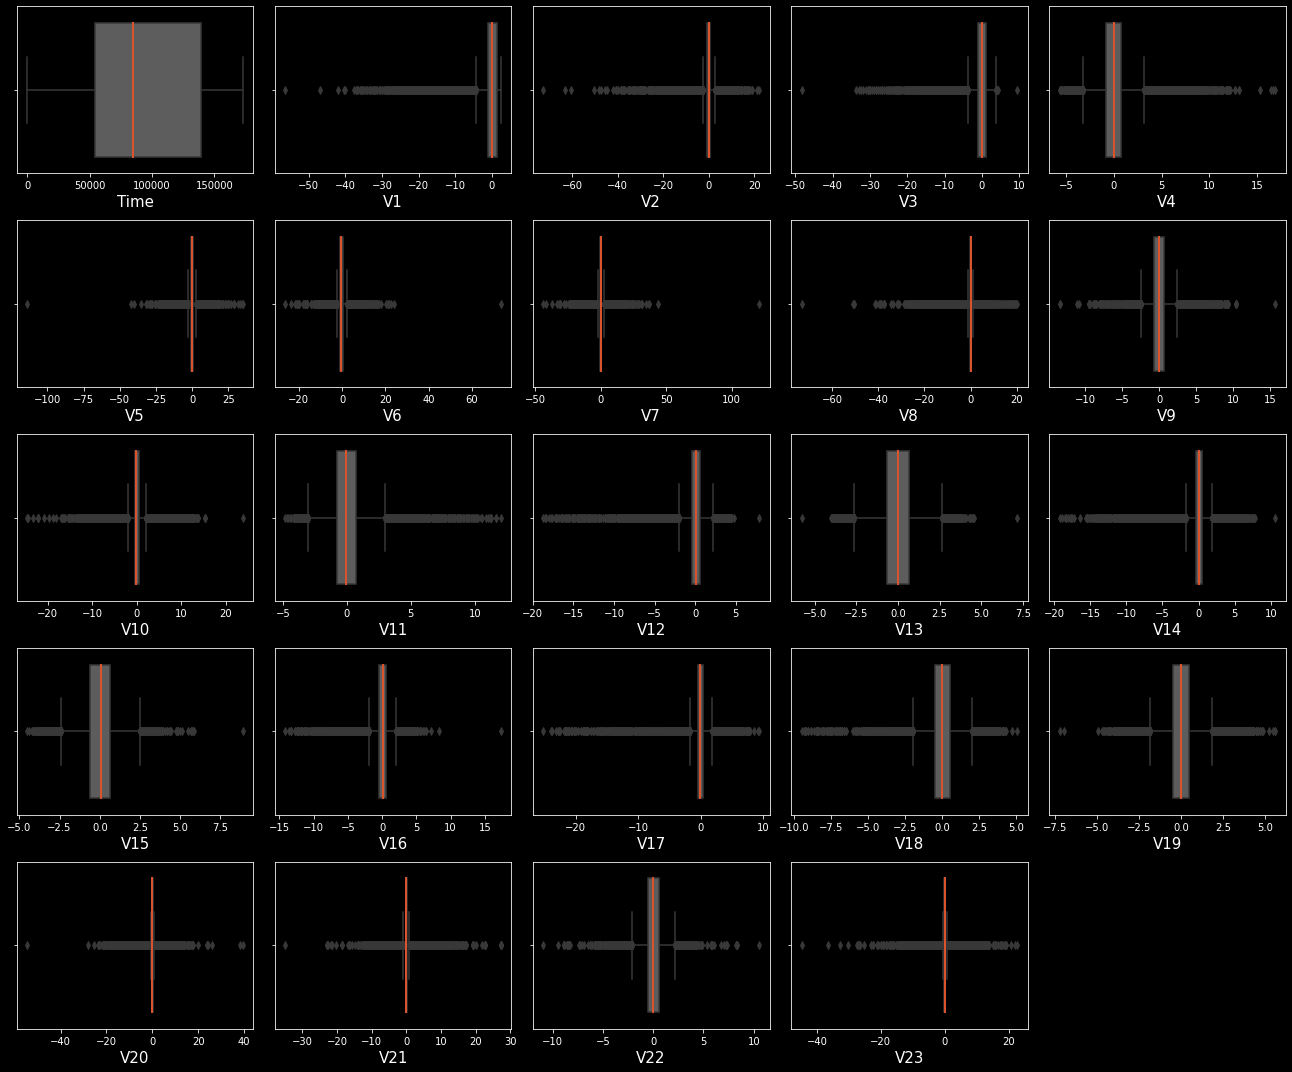

In [10]:
plt.figure(figsize = (18, 15))
plotnumber = 1

for col in df.columns:
    if plotnumber <= 24:
        ax = plt.subplot(5, 5, plotnumber)
        sns.boxplot(df[col], color="#5d5d5d", medianprops={"color": "#da532c", "linewidth": 2})
        plt.xlabel(col, fontsize = 15)
    
    plotnumber += 1
plt.tight_layout()
plt.show()

<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">03</span>
Modelado y evaluación
</div>
<a id="2"></a>

### ▣ Isolation Forest

In [11]:
contamination = y.mean()  # Sacar la media de Y (Voy a tomar este valor para el isolation forest).
contamination

0.001727485630620034

In [12]:
# Como es un set de datos con variable objetivo incluida, tomo solo las transacciones normales para entrenar (osea las que Y=0)
X_normal = X_scaled[y == 0]

In [13]:
iso_forest = IsolationForest(
    contamination=contamination,      # uso la contaminación calculada en la celda anterior (0.17%)
    random_state=42,
    n_estimators=100)

iso_forest.fit(X_normal)  # Entrenar el modelo, solicitando que aprenda como es el comportamiento habitual de estas observaciones.

# Predicciones: 1 = normal, -1 = anomalía (fraude)
y_pred_if = iso_forest.predict(X_scaled) # Clasifica cada fila como Inlier (1) u Outlier-anomalo (-1).
y_pred_if = (y_pred_if == -1).astype(int) # Convertir resultados a binarios (0 normal, 1 anomalia).

In [14]:
pd.Series(y_pred_if).value_counts().rename({0:'Normal',1:'Anomalia'}) # Conteo cuantas anomalias encontro (1) y cuantas operaciones normales.

Normal      284189
Anomalia       618
dtype: int64

In [15]:
df['pred_if'] = y_pred_if # Agrego las predicciones al dataframe original

In [16]:
GT(df.sample(5).round(2))

Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,pred_if
65863.0,0.97,-0.76,0.98,-0.21,-0.93,0.69,-0.9,0.43,0.74,-0.26,1.56,0.97,-0.34,-0.03,0.58,0.02,0.13,-0.56,-0.39,0.03,0.2,0.59,-0.02,-0.18,-0.09,1.52,-0.05,0.0,80.66,0,0
141332.0,1.86,-1.32,-1.56,-0.91,-0.63,-0.84,-0.23,-0.3,-0.75,0.96,0.79,-0.02,0.23,0.21,-0.3,1.23,-0.23,-0.63,0.75,0.35,0.59,1.28,-0.22,-0.26,0.14,0.06,-0.07,-0.05,190.55,0,0
71917.0,-0.51,1.04,-0.32,-0.42,2.7,3.54,0.44,0.54,-0.32,0.58,-0.17,-0.4,-0.07,0.14,1.26,-0.12,-0.81,0.5,0.78,0.27,0.05,0.21,-0.23,1.0,-0.1,-0.37,-0.15,-0.0,12.98,0,0
86324.0,-5.82,5.82,-4.2,0.42,-2.87,-1.85,-2.07,3.36,1.05,3.05,-1.47,1.12,-0.04,2.07,0.62,0.11,1.1,0.01,-0.11,1.1,0.03,0.15,0.66,0.32,0.24,-0.33,1.0,0.64,0.99,0,0
10981.0,-0.73,0.3,1.82,-2.59,0.28,-0.02,0.15,0.05,-0.2,-0.67,1.1,-2.91,2.07,1.05,-1.68,2.29,-0.37,-0.24,-0.5,-0.0,-0.02,-0.07,-0.44,-0.9,0.62,-0.51,-0.03,0.03,12.95,0,0


In [17]:
fraudes = df[df['pred_if'] == 1] # Solo clasificados como anomalias o fraudes.

GT(fraudes.sample(5).round(2))

Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,pred_if
18399.0,-14.47,6.5,-17.71,11.27,-4.15,-3.37,-16.54,-1.44,-6.82,-13.67,10.55,-15.02,0.17,-15.07,-0.26,-8.67,-12.8,-5.12,0.58,1.1,-2.48,0.34,-3.56,-0.82,0.15,0.76,2.71,-0.99,1.0,1,1
145773.0,-32.06,-48.06,-6.94,10.86,26.65,-20.87,-16.41,2.19,0.45,0.95,-2.45,1.03,0.68,3.68,1.23,0.62,1.26,0.64,0.34,14.94,5.25,-2.19,2.38,0.4,-1.12,-0.45,0.52,-6.33,1210.0,0,1
126801.0,-13.24,-11.48,-2.75,-0.01,4.64,-0.82,2.33,-2.15,2.54,5.21,2.28,-0.9,0.39,-2.62,1.34,1.16,-0.96,-2.92,0.69,-6.49,-3.29,1.58,2.54,-0.67,3.07,0.3,-1.07,7.28,212.53,0,1
30073.0,-6.04,5.37,-9.78,4.19,-5.1,-3.16,-6.47,4.32,-2.54,-6.52,3.43,-7.17,-0.98,-8.52,0.99,-4.79,-7.96,-2.64,0.79,0.81,0.91,-0.59,-0.1,-0.05,0.18,-0.28,1.23,0.28,89.99,0,1
32987.0,-3.76,1.53,-6.78,1.91,-25.77,15.5,21.91,-2.82,-1.04,-3.89,-0.14,-1.32,0.08,-0.37,1.17,1.92,0.32,-0.55,0.53,-5.78,-2.3,0.41,-1.39,0.95,0.16,-0.07,3.41,-2.53,4907.01,0,1


In [18]:
# Isolation Forest puede asignar scores continuos o puntajes. 
scores = -iso_forest.score_samples(X_scaled)

df['score_if'] = scores

In [19]:
GT(df.sort_values('score_if').head(10).round(2)) # Mostrar los 10 con peor puntaje.

Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,pred_if,score_if
81068.0,1.2,0.32,0.21,1.25,-0.1,-0.53,0.21,-0.09,-0.21,0.17,1.06,1.0,-0.21,0.45,-0.71,-0.18,-0.36,0.06,0.16,-0.16,0.01,0.17,-0.16,0.36,0.81,-0.28,0.01,0.0,1.0,0,0,0.35
73829.0,1.16,-0.18,0.44,0.66,-0.33,0.36,-0.39,0.27,0.54,-0.06,0.65,0.55,-1.22,0.23,-0.7,-0.31,0.06,-0.27,0.25,-0.2,-0.04,0.07,-0.1,-0.26,0.49,0.47,-0.01,-0.01,6.99,0,0,0.35
78035.0,1.22,0.26,0.18,0.51,-0.17,-0.56,-0.02,-0.03,-0.19,-0.11,1.32,0.76,0.09,-0.09,0.43,0.78,-0.37,0.32,0.21,-0.05,-0.25,-0.79,0.07,-0.04,0.22,0.1,-0.03,0.02,9.99,0,0,0.35
80537.0,1.22,0.27,0.18,0.51,-0.16,-0.56,-0.02,-0.04,-0.2,-0.12,1.33,0.8,0.16,-0.1,0.42,0.77,-0.37,0.31,0.21,-0.05,-0.25,-0.78,0.07,-0.04,0.23,0.1,-0.03,0.02,8.81,0,0,0.35
74284.0,1.24,0.29,0.19,0.5,-0.16,-0.56,-0.03,-0.03,-0.19,-0.11,1.32,0.76,0.09,-0.09,0.43,0.78,-0.37,0.32,0.22,-0.07,-0.26,-0.79,0.08,-0.04,0.23,0.1,-0.03,0.02,1.98,0,0,0.35
71288.0,1.24,0.29,0.19,0.5,-0.15,-0.56,-0.03,-0.03,-0.2,-0.11,1.33,0.79,0.16,-0.1,0.42,0.77,-0.38,0.31,0.22,-0.06,-0.26,-0.78,0.08,-0.04,0.23,0.1,-0.03,0.02,1.98,0,0,0.35
72661.0,1.23,0.28,0.18,0.5,-0.16,-0.56,-0.02,-0.03,-0.2,-0.11,1.33,0.8,0.16,-0.1,0.42,0.77,-0.37,0.31,0.21,-0.05,-0.26,-0.78,0.07,-0.04,0.23,0.1,-0.03,0.02,5.99,0,0,0.35
81366.0,1.22,0.27,0.18,0.51,-0.17,-0.56,-0.02,-0.03,-0.19,-0.11,1.32,0.76,0.09,-0.09,0.43,0.78,-0.37,0.32,0.22,-0.05,-0.26,-0.79,0.07,-0.05,0.22,0.1,-0.03,0.02,8.01,0,0,0.35
80870.0,1.24,0.29,0.19,0.5,-0.15,-0.56,-0.03,-0.03,-0.2,-0.11,1.33,0.79,0.16,-0.1,0.42,0.77,-0.38,0.31,0.22,-0.06,-0.26,-0.78,0.08,-0.04,0.23,0.1,-0.03,0.02,0.99,0,0,0.35
82468.0,1.24,0.29,0.19,0.5,-0.16,-0.56,-0.03,-0.03,-0.2,-0.11,1.33,0.8,0.16,-0.1,0.42,0.77,-0.37,0.31,0.22,-0.06,-0.26,-0.78,0.08,-0.04,0.23,0.1,-0.03,0.02,1.98,0,0,0.35


Ahora en la celda de abajo comparo:

**y_true** → las etiquetas reales de fraude (0 = normal, 1 = fraude).  
**y_pred_if** → las etiquetas predichas por Isolation Forest, convertidas a binarias.

In [20]:
y_true = df['Class'] # Defino y_true marcandole que son las etiquetas reales del dataframe.

cm = confusion_matrix(y_true, y_pred_if)
print(cm)

[[283823    492]
 [   366    126]]


In [21]:
print(classification_report(y_true, y_pred_if))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.20      0.26      0.23       492

    accuracy                           1.00    284807
   macro avg       0.60      0.63      0.61    284807
weighted avg       1.00      1.00      1.00    284807



Detectar 126 de 492 fraudes con solo 492 falsos positivos indica que el modelo está identificando ciertos patrones anómalos, pero aún tiene margen importante de mejora.

In [22]:
df['pred_if'] = (iso_forest.predict(X_scaled) == -1).astype(int)

fraudes = df[df['pred_if'] == 1].sort_values('score_if')

In [23]:
GT(fraudes.head(7).round(2))

Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,pred_if,score_if
101216.0,-14.22,-16.39,-0.3,2.15,14.64,-8.22,-9.79,-1.18,2.11,2.16,2.19,-1.97,1.35,1.71,0.32,1.17,1.19,-2.61,0.51,-6.85,-1.25,-0.31,-5.8,-0.82,0.04,0.4,4.3,-1.78,632.9,0,1,0.65
82668.0,-4.98,2.73,-7.1,-0.51,-20.45,11.04,17.42,-2.94,0.12,-1.28,0.53,-1.29,-0.19,-0.2,2.16,2.2,-0.27,-1.35,-0.03,-7.15,-2.45,0.02,-1.7,0.97,-0.44,0.87,1.14,-1.49,3690.24,0,1,0.65
130831.0,-4.22,4.78,-4.39,-0.28,-1.14,4.7,-10.71,-26.07,-2.71,-5.13,-0.73,2.82,-3.14,4.84,-2.25,1.56,0.74,0.33,-1.44,6.05,-12.5,4.22,1.92,0.21,-0.66,0.25,-0.15,0.66,52.13,0,1,0.65
157307.0,-2.77,2.14,-3.52,-1.56,-1.66,4.99,-7.86,-18.23,-1.83,-3.53,-1.4,1.85,-1.18,2.26,-2.0,0.83,2.07,-2.85,-2.48,3.65,-8.31,4.86,-0.67,-0.21,-1.2,-0.07,0.56,0.51,400.0,0,1,0.65
134161.0,-10.44,8.94,-8.27,-2.6,-3.26,-1.88,-2.67,4.79,3.35,6.47,-1.12,1.99,-0.08,2.35,-0.68,0.51,0.65,0.37,-0.49,2.6,-0.19,0.04,0.58,-1.19,1.58,0.3,2.12,1.44,0.77,0,1,0.65
53315.0,-9.02,7.56,-6.69,1.23,-6.22,-1.54,-6.28,7.61,-2.06,-1.49,-2.42,3.69,2.08,5.37,0.56,1.34,3.21,-0.05,-0.35,-1.61,1.09,0.34,1.08,0.39,0.3,-0.43,-3.55,-0.87,6.61,0,1,0.65
32987.0,-3.76,1.53,-6.78,1.91,-25.77,15.5,21.91,-2.82,-1.04,-3.89,-0.14,-1.32,0.08,-0.37,1.17,1.92,0.32,-0.55,0.53,-5.78,-2.3,0.41,-1.39,0.95,0.16,-0.07,3.41,-2.53,4907.01,0,1,0.65


In [24]:
precision, recall, thresholds = precision_recall_curve(y_true, scores)

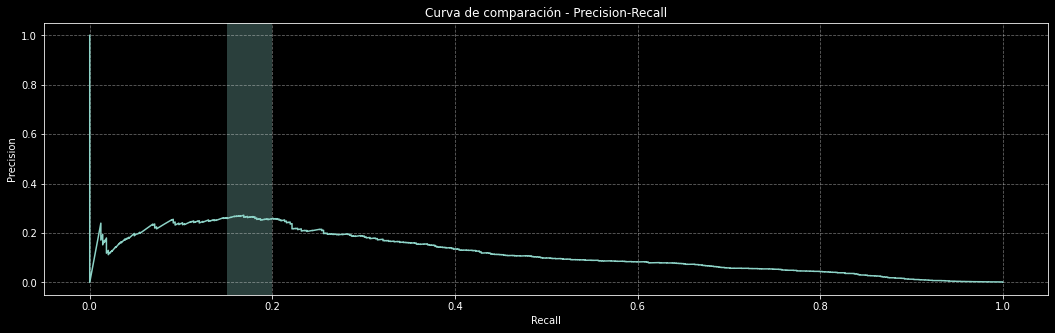

In [25]:
plt.figure(figsize=(18,5))

plt.plot(recall, precision)

# Sombrear región interesante
plt.axvspan(0.15, 0.20, alpha=0.3)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva de comparación - Precision-Recall')

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

El mejor compromiso esta cerca de (area sombreada):

Recall ≈ 0,15–0,20  
Precision ≈ 0,25–0,27

Es decir que para detectar aproximadamente el 20 % de los fraudes se tiene que aceptar que aproximadamente 1 de cada 4 alertas es un fraude real. Esto coincide bastante con los resultados de la matriz de confusión

El pico vertical al principio, es un comportamiento normal. Representa un umbral muy exigente donde el modelo detecta muy pocas operaciones, pero casi todas son realmente fraudes por eso su precision tambien es altisima.

In [26]:
# 1. Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': ['auto', 0.5, 0.7],
    'contamination': [0.001, 0.002, 0.005, 0.01, 'auto'], 
    'bootstrap': [False, True],
    'random_state': [42]
}

# 2. Dividir el dataset en un subconjunto para validación
#    Usare una parte de los datos normales y todos los datos de fraude para evaluar.

# Tomamos una muestra de los datos normales para hacer la validación más rápida
# (En un entorno real, usaríamos todo, pero para este ejercicio optimizamos tiempo)
X_normal_sample, _, y_normal_sample, _ = train_test_split(
    X_scaled[y == 0], y[y == 0], train_size=10000, random_state=42, stratify=None
)

X_val = np.vstack([X_normal_sample, X_scaled[y == 1]])
y_val = np.hstack([y_normal_sample, y[y == 1]])

print(f"Tamaño del conjunto de validación: {len(X_val)}")
print(f"Proporción de fraudes en validación: {y_val.mean():.4f}")


# 3. Función para evaluar un conjunto de parámetros
def evaluate_params(params):
    try:
        model = IsolationForest(**params)
        model.fit(X_scaled[y == 0])  # Siempre entrenamos con TODOS los datos normales
        y_pred = (model.predict(X_val) == -1).astype(int)
        
        # Métricas clave
        recall = recall_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        
        return {'recall': recall, 'precision': precision, 'f1': f1}
    except Exception as e:
        print(f"Error con los params {params}: {e}")
        return {'recall': 0, 'precision': 0, 'f1': 0}

# 4. Búsqueda Aleatoria de Parámetros
best_score = -1
best_params = None
best_metrics = {}

# Número de combinaciones a probar (ajusta según tu tiempo de ejecución)
n_iter = 20

for i, params in enumerate(ParameterSampler(param_grid, n_iter=n_iter, random_state=42)):
    print(f"Evaluando combinación {i+1}/{n_iter}: {params}")
    metrics = evaluate_params(params)
    
    # Buscamos maximizar el F1-Score (balance entre precision y recall)
    # Si quieres priorizar recall, cambia a 'recall'
    score = metrics['f1']
    
    if score > best_score:
        best_score = score
        best_params = params
        best_metrics = metrics
        print(f"  ** Nuevo mejor F1: {best_score:.4f} **")

print("\n--- Mejores Parámetros Encontrados ---")
print(f"Parámetros: {best_params}")
print(f"Métricas: {best_metrics}")

Tamaño del conjunto de validación: 10492
Proporción de fraudes en validación: 0.0469
Evaluando combinación 1/20: {'random_state': 42, 'n_estimators': 100, 'max_samples': 0.5, 'contamination': 'auto', 'bootstrap': False}
  ** Nuevo mejor F1: 0.7164 **
Evaluando combinación 2/20: {'random_state': 42, 'n_estimators': 100, 'max_samples': 0.5, 'contamination': 0.005, 'bootstrap': False}
  ** Nuevo mejor F1: 0.7741 **
Evaluando combinación 3/20: {'random_state': 42, 'n_estimators': 100, 'max_samples': 'auto', 'contamination': 0.002, 'bootstrap': True}
Evaluando combinación 4/20: {'random_state': 42, 'n_estimators': 100, 'max_samples': 0.7, 'contamination': 0.005, 'bootstrap': True}
  ** Nuevo mejor F1: 0.7996 **
Evaluando combinación 5/20: {'random_state': 42, 'n_estimators': 50, 'max_samples': 'auto', 'contamination': 0.001, 'bootstrap': False}
Evaluando combinación 6/20: {'random_state': 42, 'n_estimators': 200, 'max_samples': 0.7, 'contamination': 0.005, 'bootstrap': False}
Evaluando comb

In [27]:
# Entonces vuelvo a pasar el algoritmo con los mejores parametros posibles.
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples=0.7,
    contamination=0.005,
    bootstrap=True,
    random_state=42
)

iso_forest.fit(X_normal)

y_pred_if = iso_forest.predict(X_scaled)
y_pred_if = (y_pred_if == -1).astype(int)

In [28]:
cm = confusion_matrix(y_true, y_pred_if)
print(cm)

[[282893   1422]
 [   129    363]]


Isolation Forest funciona buscando qué tan "aislado" está un dato. Es normal que tenga un número relativamente alto de Falsos Positivos ($1,422$, Casos normales que clasificó como anomalías) porque no sabe qué es "malo" o "bueno" por definición, solo sabe qué es raro.

### ▣ XGBoost

In [29]:
# Cargamos los datos y los dividimos en conjuntos para entrenar y testear.
data = df
y = data["Class"] # Aca le pido que Y sea mi objetivo a predecir
X = data.drop(["Class", "score_if", "pred_if"], axis=1) # Saco la variable "class", y ambas "score_if", "pred_if" para que sea el xgboost con los datos base

(X_train, X_test,
 y_train, y_test) = train_test_split(X,
                                     y,
                                     test_size=0.30,
                                     random_state=42,
                                     stratify=y) # Las proporciones se mantienen en ambos conjuntos. Tanto train como test tendrian similares cantidades de ambas clases.

In [30]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print("Proporción de clases:", ratio)
print()
print("Muestra el resultado, indicando cuántas veces es más frecuente la clase mayoritaria que la minoritaria.")
print("Un valor cercano a 1 = clases equilibradas. Un valor muy alto = desbalance de clases.")

Proporción de clases: 578.546511627907

Muestra el resultado, indicando cuántas veces es más frecuente la clase mayoritaria que la minoritaria.
Un valor cercano a 1 = clases equilibradas. Un valor muy alto = desbalance de clases.


In [31]:
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,  # balanceo las clases segun el ratio calculado en celda anterior.
    eval_metric="auc")

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [32]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

AUC: 0.9713863491253725

Matriz de confusión:
 [[85269    26]
 [   28   120]]

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.82      0.81      0.82       148

    accuracy                           1.00     85443
   macro avg       0.91      0.91      0.91     85443
weighted avg       1.00      1.00      1.00     85443



### ▣ XGBoost + if_score (Staking Hibrido)

In [33]:
data = df.copy()
y = data["Class"]
X = data.drop(columns=["Class", "pred_if"])  # Incluye score_if como features y pred_if lo saco porque es redundante/repetitivo.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y)

scale_pos_weight: 578.55


In [34]:
xgb_hybrid = XGBClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio*1.50, #1.75 de castigo a los errores del positivo.
    eval_metric="auc", )

xgb_hybrid.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [35]:
y_pred_hyb  = xgb_hybrid.predict(X_test)
y_prob_hyb  = xgb_hybrid.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_prob_hyb))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred_hyb))
print("\n", classification_report(y_test, y_pred_hyb))

AUC: 0.9732158502367776

Matriz de confusión:
 [[85205    90]
 [   23   125]]

               precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.58      0.84      0.69       148

    accuracy                           1.00     85443
   macro avg       0.79      0.92      0.84     85443
weighted avg       1.00      1.00      1.00     85443



<div style="
    background-color:#111827;
    color:#D1D5DB;
    padding:12px 16px;
    border-left:5px solid #F59E0B;
    border-radius:6px;
    font-weight:600;
    letter-spacing:0.3px;
    margin:20px 0;
    font-size:16px;
">
<span style="
    background:#F59E0B;
    color:#000;
    padding:4px 10px;
    border-radius:20px;
    font-size:13px;
    font-weight:700;
">04</span>
Conclusiones
</div>
<a id="3"></a>

XGBoost aprendió a distinguir cuándo el score de "rareza" de Isolation Forest realmente significaba una anomalía real y cuándo era solo un dato normal pero atípico. Porque redujo los falsos positivos.

Entonces Isolation Forest hizo el trabajo sucio: Midió qué tan "extraño" o alejado del comportamiento común era cada registro, sintetizando interacciones complejas de las variables en un solo score numérico.

XGBoost le dio el sentido comercial/real: Como XGBoost sí ve las etiquetas reales (sabe qué es fraude y qué no), tomó ese score de "rareza" y aprendió una regla del tipo: "Si el score de iForest es alto Y además la variable X cumple tal condición, entonces SÍ es una anomalía real. Si el score es alto pero la variable X no cumple la condición, es solo un cliente VIP o un caso raro pero legítimo".

In [36]:
comparacion = pd.DataFrame({
    "Modelo": ["XGBoost base", "XGBoost + IF Score"],
    "AUC":    [roc_auc_score(y_test, y_prob),
               roc_auc_score(y_test, y_prob_hyb)],
    "Recall fraude": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred_hyb, output_dict=True)["1"]["recall"]
    ],
    "Precision fraude": [
        classification_report(y_test, y_pred, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred_hyb, output_dict=True)["1"]["precision"]
    ]
})

print(comparacion.round(4).to_string(index=False))

            Modelo    AUC  Recall fraude  Precision fraude
      XGBoost base 0.9714         0.8108            0.8219
XGBoost + IF Score 0.9732         0.8446            0.5814


Dado que:

if_score es la tercera característica más importante,
el AUC aumentó,
la precision aumentó,
el recall solo cayó de 0,8108 a 0,8041,

la conclusión técnica sería algo similar a:

La incorporación del score de anomalía generado por Isolation Forest como característica adicional permitió mejorar la capacidad discriminatoria global del modelo XGBoost, incrementando el AUC y la precisión. Si bien se observó una leve reducción en el recall, la importancia relativa de if_score (tercera variable más relevante) sugiere que el modelo aprendió a utilizar eficazmente esta información para reducir falsos positivos y refinar la identificación de transacciones fraudulentas.

In [38]:
explainer = shap.TreeExplainer(xgb_hybrid)
shap_values = explainer(X_test)

print(f"Shape SHAP values: {shap_values.shape}")  # debe ser (n_samples, n_features)

Shape SHAP values: (85443, 31)


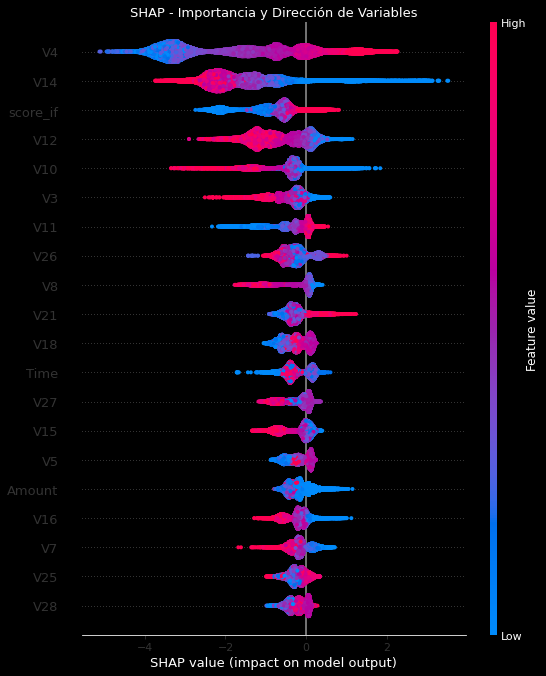

In [39]:
plt.figure(figsize=(18, 7))
shap.summary_plot(
    shap_values,   # sin [:, :, 1]
    X_test,
    plot_type="dot",
    show=False
)
plt.title("SHAP - Importancia y Dirección de Variables", fontsize=13)
plt.tight_layout()
plt.show()

- Cada punto representa una observación.  
- El eje X muestra el valor SHAP:  
Derecha (+): aumenta la probabilidad de fraude.  
Izquierda (-): disminuye la probabilidad de fraude.  
- El color indica el valor de la variable:  
Azul = valor bajo.  
Rosa/Rojo = valor alto.  
- Las variables están ordenadas por importancia global (de arriba hacia abajo)

Se logró un modelo híbrido con Isolation Forest + XGBoost optimizado mediante cambios en los hiperparametros, alcanzando un Recall del 84% en el set de test.
El impacto operativo es que de cada 100 casos de anomalías/fraudes reales, el sistema alerta automáticamente 84. Esto reduce el riesgo fiscal y financiero, tambien permite focalizar esfuerzos en un universo delimitado de alertas."

#### Paso final para despliegue

In [1]:
## Exporto dataset reducido para deploy en Streamlit

In [41]:
fraudes = df[df['Class'] == 1]
normales = df[df['Class'] == 0].sample(20000, random_state=42)

df_small = pd.concat([fraudes, normales]).sample(frac=1, random_state=42)
df_small.to_csv('creditcard_small.csv', index=False)

print(f"Shape: {df_small.shape}")
print(f"Fraudes: {df_small['Class'].sum()} ({df_small['Class'].mean():.2%})")
print(f"Tamaño aprox: {df_small.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: (20492, 33)
Fraudes: 492 (2.40%)
Tamaño aprox: 5.5 MB


<div style="
    margin-top:40px;
    padding:16px;
    border-radius:12px;
    background:linear-gradient(90deg,#0B1220,#111827);
    border-left:4px solid #F59E0B;
    color:#E5E7EB;
    font-size:13px;
    line-height:1.6;
">
<div style="font-weight:600; font-size:14px;">
Néstor Díaz
</div>

<div style="color:#94A3B8;">
Contador Público · Data Analyst · Machine Learning
</div>

<div style="margin-top:8px; color:#F59E0B;">
Proyecto: XGBoost con Score de Anomalía de Isolation Forest para Detección de Fraudes.
</div>
</div>